# Last.fm Music Clustering Analysis
## Clustering vs Bi-Clustering Comparison

**Objective**: Compare traditional K-Means clustering with Bi-Clustering (Spectral Co-Clustering) for music recommendation using the Last.fm dataset.

**Author**: ML2 Group  
**Date**: February 2026

---

### Project Overview

This notebook implements and compares:
1. **K-Means Clustering**: User segmentation based on listening patterns
2. **Bi-Clustering**: Simultaneous user-artist community detection

**Dataset**: Last.fm-1K (992 users, 177K+ artists, 19M+ listening records)

## 1. Setup and Imports

In [5]:
# Standard imports
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-reload local modules in notebook sessions
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('load_ext', 'autoreload')
    ip.run_line_magic('autoreload', '2')

# Add parent directory to path (to access config and src modules)
project_dir = os.path.abspath('..')
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print(f"📁 Working from: {os.getcwd()}")
print(f"📁 Project directory: {project_dir}")

# Import project modules
try:
    import config as config_module
    import src.data_loader as data_loader_module
    import src.feature_engineering as feature_engineering_module
    import src.clustering_model as clustering_model_module
    import src.biclustering_model as biclustering_model_module
    import src.evaluation as evaluation_module
    import src.visualization as visualization_module
    import src.utils as utils_module

    # Ensure latest code is loaded
    importlib.reload(config_module)
    importlib.reload(data_loader_module)
    importlib.reload(feature_engineering_module)
    importlib.reload(clustering_model_module)
    importlib.reload(biclustering_model_module)
    importlib.reload(evaluation_module)
    importlib.reload(visualization_module)
    importlib.reload(utils_module)

    from config import *
    from src.data_loader import LastFMDataLoader
    from src.feature_engineering import FeatureEngineer
    from src.clustering_model import UserClusteringModel
    from src.biclustering_model import BiClusteringModel
    from src.evaluation import ModelComparison
    from src.visualization import ClusteringVisualizer
    from src.utils import save_model, save_results, create_project_structure
    
    print("✅ All modules imported successfully!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print(f"   Make sure you're running from the notebooks/ folder")
    raise

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(f"🎲 Random State: {RANDOM_STATE}")
print(f"📊 Sample Users: {SAMPLE_USERS}")
print(f"🎯 Optimal Clusters: {OPTIMAL_CLUSTERS}")
print(f"🔗 Bi-clusters: {N_BICLUSTERS}")

📁 Working from: c:\Users\NCPC\OneDrive\Desktop\ML2\Grp\lastfm-clustering-project\notebooks
📁 Project directory: c:\Users\NCPC\OneDrive\Desktop\ML2\Grp\lastfm-clustering-project
✅ All modules imported successfully!
🎲 Random State: 42
📊 Sample Users: 500
🎯 Optimal Clusters: 5
🔗 Bi-clusters: 4


In [6]:
# Create output directories
create_project_structure('..')

print("✅ Project structure created!")

INFO:src.utils:Created directory: ..\output
INFO:src.utils:Created directory: ..\output/models
INFO:src.utils:Created directory: ..\output/plots
INFO:src.utils:Created directory: ..\output/results


✅ Project structure created!


## 2. Data Loading and Preprocessing

Based on the README.txt, the dataset contains:
- **userid-timestamp-artid-artname-traid-traname.tsv**: Listening history
- **userid-profile.tsv**: User demographics

We'll load a sample of users due to the large dataset size (19M+ records).

In [7]:
# Initialize data loader
loader = LastFMDataLoader(
    listening_file=LISTENING_FILE,
    profile_file=PROFILE_FILE
)

print("📂 Loading data...")
print(f"Listening file: {LISTENING_FILE}")
print(f"Profile file: {PROFILE_FILE}")

📂 Loading data...
Listening file: c:\Users\NCPC\OneDrive\Desktop\ML2\Grp\lastfm-clustering-project\..\lastfm-dataset-1K\userid-timestamp-artid-artname-traid-traname.tsv
Profile file: c:\Users\NCPC\OneDrive\Desktop\ML2\Grp\lastfm-clustering-project\..\lastfm-dataset-1K\userid-profile.tsv


In [8]:
# Load user profiles
profile_data = loader.load_profile_data()

print("\n📊 User Profile Data:")
display(profile_data.head())
print(f"\nShape: {profile_data.shape}")
print(f"\nInfo:")
print(profile_data.info())

INFO:src.data_loader:Loading user profile data...
INFO:src.data_loader:Loaded 992 user profiles



📊 User Profile Data:


,#id,gender,age,country,registered
0,user_000001,m,NaN,Japan,"Aug 13, 2006"
1,user_000002,f,NaN,Peru,"Feb 24, 2006"
2,user_000003,m,22.0,United States,"Oct 30, 2005"
3,user_000004,f,NaN,NaN,"Apr 26, 2006"
4,user_000005,m,NaN,Bulgaria,"Jun 29, 2006"



Shape: (992, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   #id         992 non-null    object 
 1   gender      884 non-null    object 
 2   age         286 non-null    float64
 3   country     907 non-null    object 
 4   registered  984 non-null    object 
dtypes: float64(1), object(4)
memory usage: 38.9+ KB
None


In [9]:
# Load listening data (sample for efficiency)
listening_data = loader.load_listening_data(
    nrows=1000000,  # Load first 1M records
    sample_users=SAMPLE_USERS  # Sample specific number of users
)

print("\n📊 Listening History Data:")
display(listening_data.head(10))
print(f"\nShape: {listening_data.shape}")
print(f"\nColumns: {listening_data.columns.tolist()}")

INFO:src.data_loader:Loading listening history data...


INFO:src.data_loader:Loaded 1000000 listening records
INFO:src.data_loader:Sampling 500 users...



📊 Listening History Data:


,userid,timestamp,artist_mbid,artist_name,track_mbid,track_name
0,user_000001,2009-05-04T23:08:57Z,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Deep Dish,NaN,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
1,user_000001,2009-05-04T13:54:10Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Composition 0919 (Live_2009_4_15)
2,user_000001,2009-05-04T13:52:04Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc2 (Live_2009_4_15)
3,user_000001,2009-05-04T13:42:52Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Hibari (Live_2009_4_15)
4,user_000001,2009-05-04T13:42:11Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc1 (Live_2009_4_15)
5,user_000001,2009-05-04T13:38:31Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,To Stanford (Live_2009_4_15)
6,user_000001,2009-05-04T13:33:28Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Improvisation (Live_2009_4_15)
7,user_000001,2009-05-04T13:23:45Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Glacier (Live_2009_4_15)
8,user_000001,2009-05-04T13:19:22Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Parolibre (Live_2009_4_15)
9,user_000001,2009-05-04T13:13:38Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Bibo No Aozora (Live_2009_4_15)



Shape: (1000000, 6)

Columns: ['userid', 'timestamp', 'artist_mbid', 'artist_name', 'track_mbid', 'track_name']


In [10]:
# Preprocess data
listening_data = loader.preprocess_data(
    min_artist_plays=MIN_ARTIST_PLAYS,
    min_user_plays=MIN_USER_PLAYS
)

print("\n✨ After preprocessing:")
display(listening_data.head())
print(f"\nShape: {listening_data.shape}")

INFO:src.data_loader:Preprocessing data...
INFO:src.data_loader:Filtered to 10027 artists with >=5 plays
INFO:src.data_loader:Filtered to 41 users with >=20 plays



✨ After preprocessing:


,userid,timestamp,artist_mbid,artist_name,track_mbid,track_name
0,user_000001,2009-05-04 23:08:57+00:00,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Deep Dish,NaN,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
1,user_000001,2009-05-04 13:54:10+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Composition 0919 (Live_2009_4_15)
2,user_000001,2009-05-04 13:52:04+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc2 (Live_2009_4_15)
3,user_000001,2009-05-04 13:42:52+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Hibari (Live_2009_4_15)
4,user_000001,2009-05-04 13:42:11+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc1 (Live_2009_4_15)



Shape: (976911, 6)


In [11]:
# Get dataset statistics
stats = loader.get_statistics()

print("\n📈 Dataset Statistics:")
print("=" * 50)
for key, value in stats.items():
    print(f"{key}: {value}")
print("=" * 50)


📈 Dataset Statistics:
total_records: 976911
unique_users: 41
unique_artists: 10027
unique_tracks: 119911
date_range: (Timestamp('2005-02-28 23:20:27+0000', tz='UTC'), Timestamp('2009-06-19 17:12:30+0000', tz='UTC'))


## 3. Feature Engineering

Create two types of features:
1. **User-Artist Matrix**: For bi-clustering (users × artists)
2. **User-Level Features**: For K-Means clustering (aggregated listening patterns)

In [12]:
# Initialize feature engineer
feature_eng = FeatureEngineer(
    listening_data=listening_data,
    profile_data=profile_data
)

print("🔧 Feature Engineer initialized!")

🔧 Feature Engineer initialized!


### 3.1 User-Artist Matrix (for Bi-Clustering)

In [13]:
# Create user-artist matrix
user_artist_matrix = feature_eng.create_user_artist_matrix(normalize=False)

print(f"\n📊 User-Artist Matrix:")
print(f"Shape: {user_artist_matrix.shape}")
print(f"Users: {user_artist_matrix.shape[0]}")
print(f"Artists: {user_artist_matrix.shape[1]}")
print(f"Sparsity: {(user_artist_matrix == 0).sum().sum() / user_artist_matrix.size:.2%}")

display(user_artist_matrix.iloc[:5, :5])

INFO:src.feature_engineering:Creating user-artist matrix...
INFO:src.feature_engineering:Created matrix with shape: (41, 10027)
INFO:src.feature_engineering:Users: 41, Artists: 10027



📊 User-Artist Matrix:
Shape: (41, 10027)
Users: 41
Artists: 10027
Sparsity: 92.89%


artist_name,!!!,!4,$Olal,(777-111) Holiday,(Həd) P.E.
userid,,,,,
user_000001,0.0,0.0,0.0,0.0,0.0
user_000002,0.0,0.0,0.0,0.0,0.0
user_000003,0.0,0.0,0.0,0.0,0.0
user_000004,48.0,0.0,0.0,0.0,0.0
user_000005,0.0,0.0,0.0,0.0,0.0


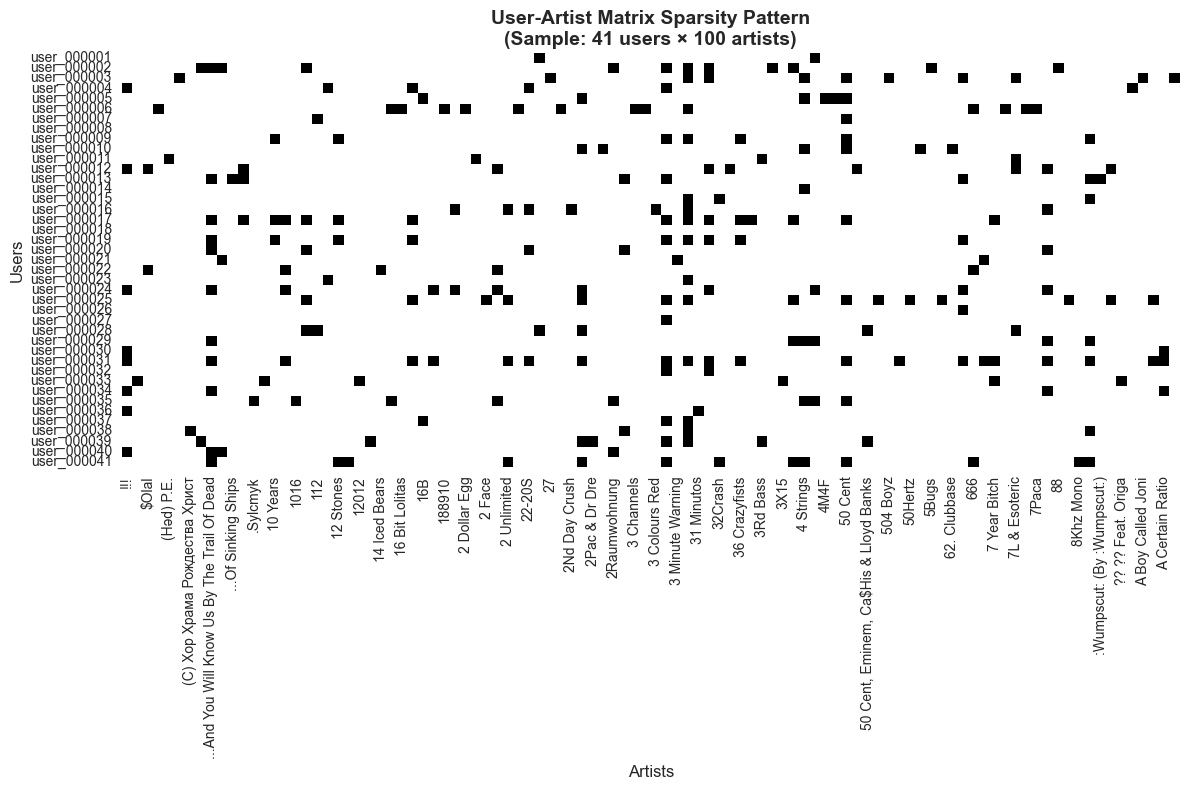

✅ Plot saved to: output/plots/matrix_sparsity.png


In [14]:
# Visualize matrix sparsity
fig, ax = plt.subplots(figsize=(12, 8))

sample_users = min(100, user_artist_matrix.shape[0])
sample_artists = min(100, user_artist_matrix.shape[1])

matrix_sample = user_artist_matrix.iloc[:sample_users, :sample_artists]

sns.heatmap(
    matrix_sample > 0,
    cmap='binary',
    cbar=False,
    ax=ax
)

ax.set_title(f'User-Artist Matrix Sparsity Pattern\n(Sample: {sample_users} users × {sample_artists} artists)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Artists', fontsize=12)
ax.set_ylabel('Users', fontsize=12)

plt.tight_layout()
plt.savefig('../output/plots/matrix_sparsity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/matrix_sparsity.png")

### 3.2 User-Level Features (for K-Means Clustering)

In [15]:
# Create user-level features
user_features = feature_eng.create_user_features()

print(f"\n📊 User Features:")
print(f"Shape: {user_features.shape}")
print(f"\nFeatures created:")
for col in user_features.columns:
    print(f"  - {col}")

display(user_features.head(10))

INFO:src.feature_engineering:Creating user-level features...
INFO:src.feature_engineering:Adding profile features...
INFO:src.feature_engineering:Created 13 features for 41 users



📊 User Features:
Shape: (41, 13)

Features created:
  - total_plays
  - unique_artists
  - unique_tracks
  - artist_diversity
  - track_diversity
  - listening_span_days
  - first_listen
  - last_listen
  - plays_per_day
  - top_artist_concentration
  - age
  - is_male
  - is_female


,total_plays,unique_artists,unique_tracks,artist_diversity,track_diversity,listening_span_days,first_listen,last_listen,plays_per_day,top_artist_concentration,age,is_male,is_female
userid,,,,,,,,,,,,,
user_000001,16213,412,2821,0.025412,0.173996,995,2006-08-13 13:59:20+00:00,2009-05-04 23:08:57+00:00,16.278112,0.052735,22.5,1,0
user_000002,56999,1031,7875,0.018088,0.138160,1159,2006-02-24 18:05:42+00:00,2009-04-28 18:41:35+00:00,49.137069,0.042299,22.5,0,1
user_000003,19013,690,4301,0.036291,0.226214,1268,2005-10-30 22:23:21+00:00,2009-04-21 16:56:35+00:00,14.982664,0.047073,22.0,1,0
user_000004,17640,1284,5452,0.072789,0.309070,730,2007-04-19 19:15:15+00:00,2009-04-19 13:52:05+00:00,24.131327,0.030726,22.5,0,1
user_000005,19633,639,1524,0.032547,0.077624,996,2006-08-12 16:36:44+00:00,2009-05-04 21:54:33+00:00,19.692076,0.097031,22.5,1,0
user_000006,27742,1054,6877,0.037993,0.247891,1080,2006-05-18 23:45:22+00:00,2009-05-03 20:14:48+00:00,25.663275,0.038101,24.0,0,0
user_000007,2008,232,807,0.115538,0.401892,1195,2006-01-23 08:13:39+00:00,2009-05-03 00:48:08+00:00,1.678930,0.090637,22.5,0,1
user_000008,37147,104,554,0.002800,0.014914,129,2008-12-21 02:41:01+00:00,2009-04-29 10:10:00+00:00,285.746154,0.713274,23.0,1,0
user_000009,5029,458,2410,0.091072,0.479221,841,2007-01-13 19:13:49+00:00,2009-05-04 10:53:47+00:00,5.972684,0.121495,19.0,0,1


In [16]:
# Feature statistics
print("\n📊 Feature Statistics:")
display(user_features.describe())


📊 Feature Statistics:


,total_plays,unique_artists,unique_tracks,artist_diversity,track_diversity,listening_span_days,plays_per_day,top_artist_concentration,age,is_male,is_female
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,23827.097561,712.853659,4653.268293,0.052305,0.274473,978.756098,30.170681,0.089784,24.012195,0.487805,0.341463
std,21306.079915,552.636208,3611.596572,0.052966,0.181388,365.062856,44.711585,0.115819,4.565479,0.506061,0.480091
min,341.000000,100.000000,268.000000,0.002800,0.014914,129.000000,0.371460,0.012761,19.000000,0.000000,0.000000
25%,8648.000000,335.000000,1973.000000,0.022611,0.117567,730.000000,10.266508,0.032615,22.000000,0.000000,0.000000
50%,17640.000000,508.000000,3576.000000,0.032547,0.226214,1061.000000,19.692076,0.057746,22.500000,0.000000,0.000000
75%,32990.000000,1054.000000,6731.000000,0.072789,0.412642,1259.000000,33.801230,0.105572,25.000000,1.000000,1.000000
max,95868.000000,2774.000000,16255.000000,0.293255,0.785924,1522.000000,285.746154,0.713274,38.000000,1.000000,1.000000


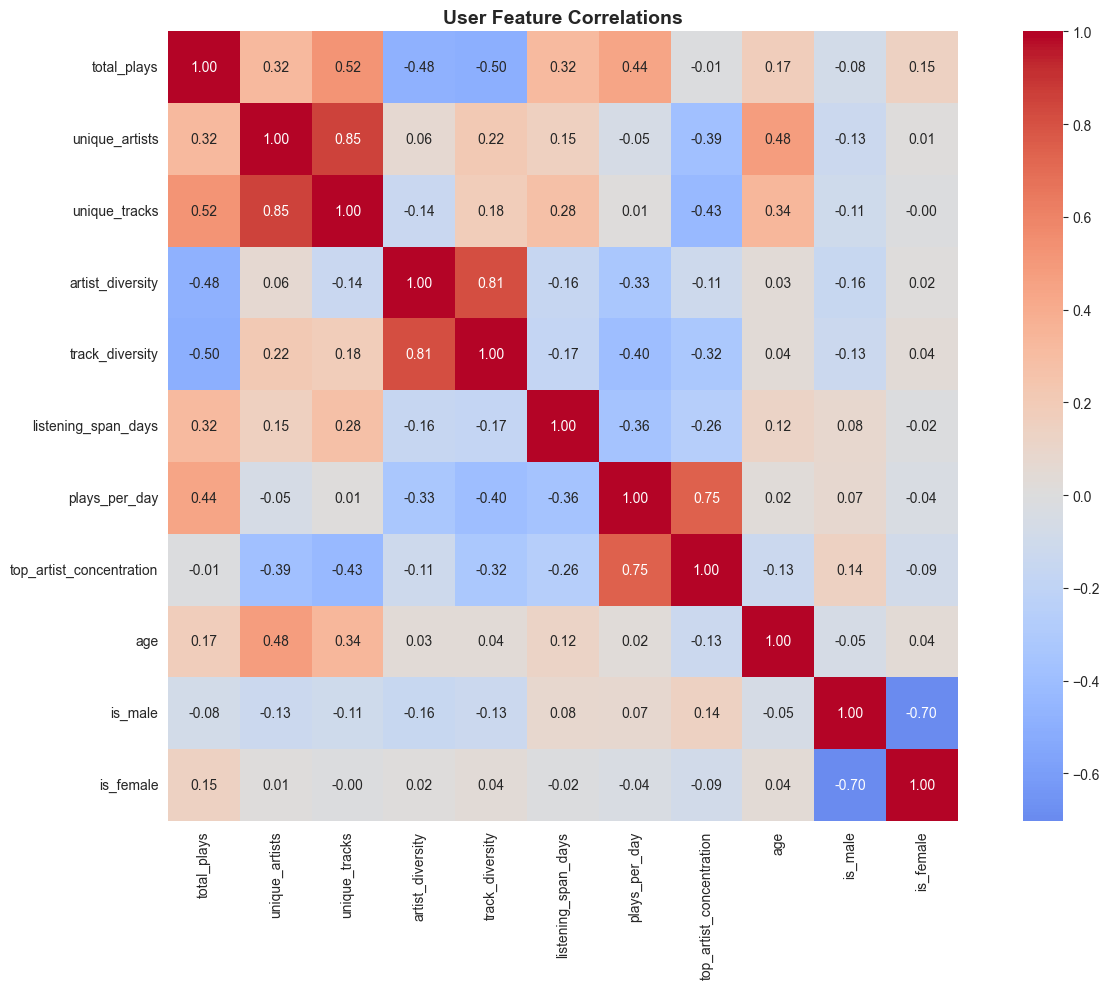

✅ Plot saved to: output/plots/feature_correlations.png


In [17]:
# Feature correlations
fig, ax = plt.subplots(figsize=(14, 10))

# Select numeric features only
numeric_features = user_features.select_dtypes(include=[np.number])

sns.heatmap(
    numeric_features.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    ax=ax
)

ax.set_title('User Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/plots/feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/feature_correlations.png")

In [18]:
# Scale features for clustering
user_features_scaled, scaler = feature_eng.scale_features(
    user_features,
    method='standard'
)

print(f"\n✨ Features scaled using StandardScaler")
print(f"Scaled shape: {user_features_scaled.shape}")
print(f"Sample scaled values:\n{user_features_scaled[:3]}")

INFO:src.feature_engineering:Scaling features using standard method...



✨ Features scaled using StandardScaler
Scaled shape: (41, 11)
Sample scaled values:
[[-0.36180688 -0.55116026 -0.51363164 -0.51406195 -0.56081843  0.04504895
  -0.31457516 -0.32385418 -0.33533851  1.02469508 -0.7200823 ]
 [ 1.57626329  0.58284024  0.90313375 -0.6540516  -0.76083791  0.49986746
   0.42946373 -0.41508351 -0.33533851 -0.97590007  1.38873015]
 [-0.22875641 -0.04186763 -0.09874981 -0.30610846 -0.26936423  0.80215537
  -0.34390854 -0.37335149 -0.44621656  1.02469508 -0.7200823 ]]


## 4. K-Means Clustering

Traditional clustering approach - group users based on their listening behavior features.

### 4.1 Finding Optimal Number of Clusters

In [19]:
# Initialize clustering model
kmeans_model = UserClusteringModel(random_state=RANDOM_STATE)

# Find optimal clusters
print("🔍 Finding optimal number of clusters...")
print("Testing K values from 3 to 10...")
print()

metrics = kmeans_model.find_optimal_clusters(
    data=user_features_scaled,
    k_range=N_CLUSTERS_RANGE
)

print("\n✅ Optimal cluster search complete!")

INFO:src.clustering_model:Finding optimal clusters in range range(3, 11)...


🔍 Finding optimal number of clusters...
Testing K values from 3 to 10...



INFO:src.clustering_model:K=3: Silhouette=0.185, Davies-Bouldin=1.297
INFO:src.clustering_model:K=4: Silhouette=0.187, Davies-Bouldin=1.230
INFO:src.clustering_model:K=5: Silhouette=0.191, Davies-Bouldin=1.162
INFO:src.clustering_model:K=6: Silhouette=0.202, Davies-Bouldin=1.070
INFO:src.clustering_model:K=7: Silhouette=0.187, Davies-Bouldin=0.968
INFO:src.clustering_model:K=8: Silhouette=0.196, Davies-Bouldin=0.930
INFO:src.clustering_model:K=9: Silhouette=0.193, Davies-Bouldin=1.061
INFO:src.clustering_model:K=10: Silhouette=0.177, Davies-Bouldin=0.991
INFO:src.clustering_model:Optimal K (by silhouette score): 6



✅ Optimal cluster search complete!


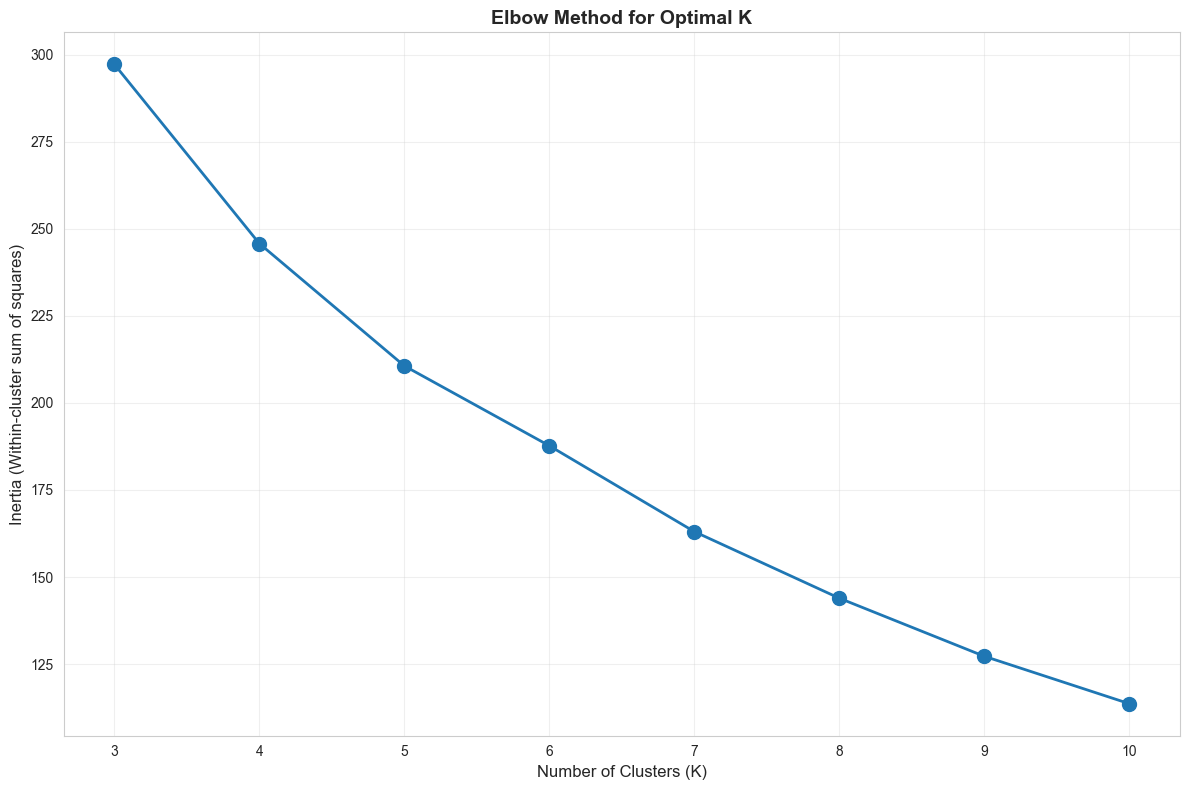

✅ Plot saved to: output/plots/kmeans_elbow_curve.png


In [20]:
# Visualize elbow curve
viz = ClusteringVisualizer()

fig_elbow = viz.plot_elbow_curve(
    k_values=metrics['k_values'],
    inertias=metrics['inertia']
)

plt.savefig('../output/plots/kmeans_elbow_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/kmeans_elbow_curve.png")

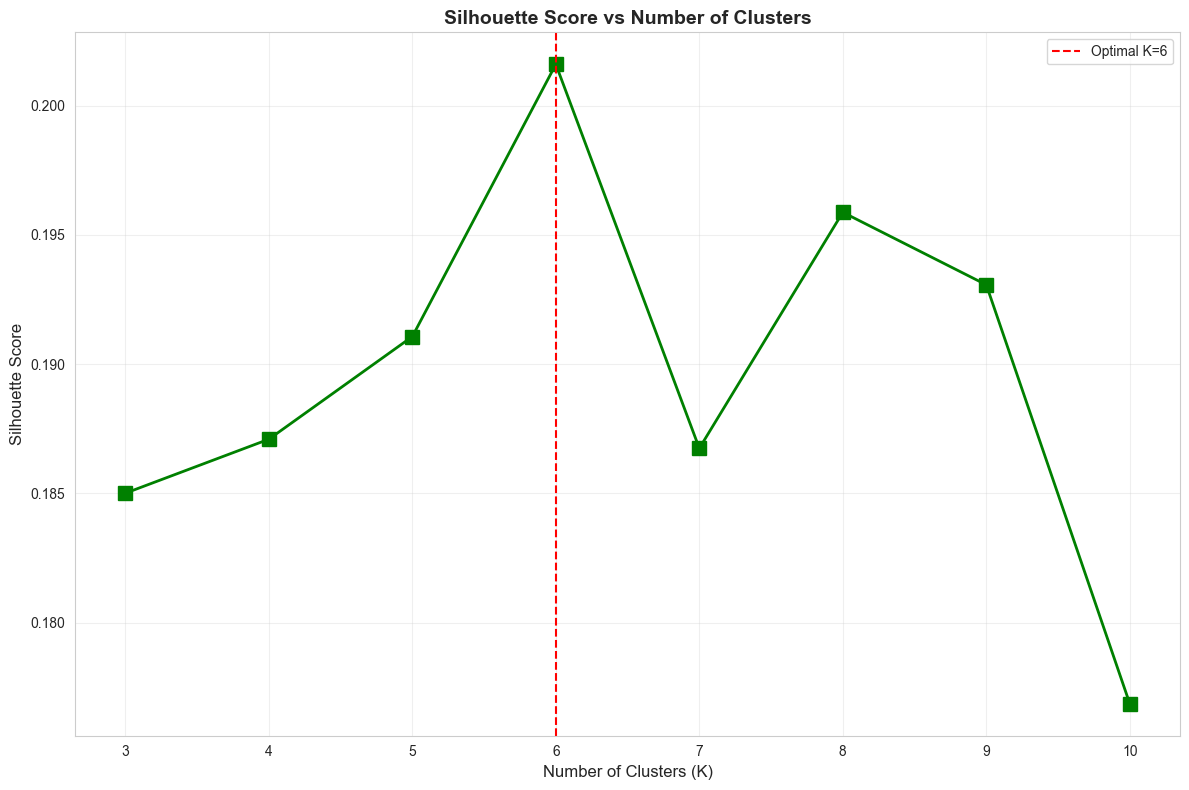

✅ Plot saved to: output/plots/kmeans_silhouette.png


In [21]:
# Visualize silhouette scores
fig_silhouette = viz.plot_silhouette_scores(
    k_values=metrics['k_values'],
    silhouette_scores=metrics['silhouette']
)

plt.savefig('../output/plots/kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/kmeans_silhouette.png")

### 4.2 Fit K-Means Model

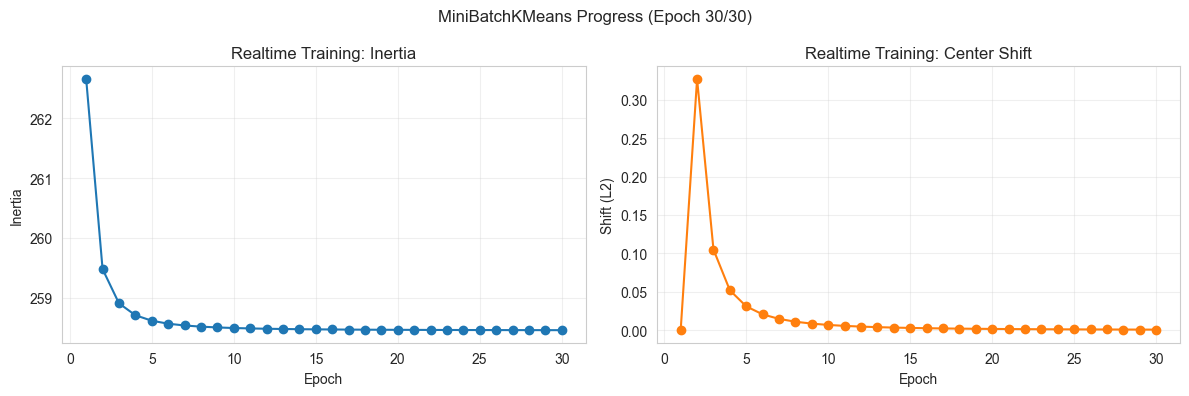

INFO:src.clustering_model:Epoch 030/30: inertia=258.45, center_shift=0.000702
INFO:src.clustering_model:Realtime clustering complete. Final silhouette: 0.169



✅ K-Means realtime training complete!

Final Metrics:
  Silhouette Score: 0.1689
  Davies-Bouldin Index: 1.4064
  Calinski-Harabasz Score: 6.71
  Final Inertia: 258.45


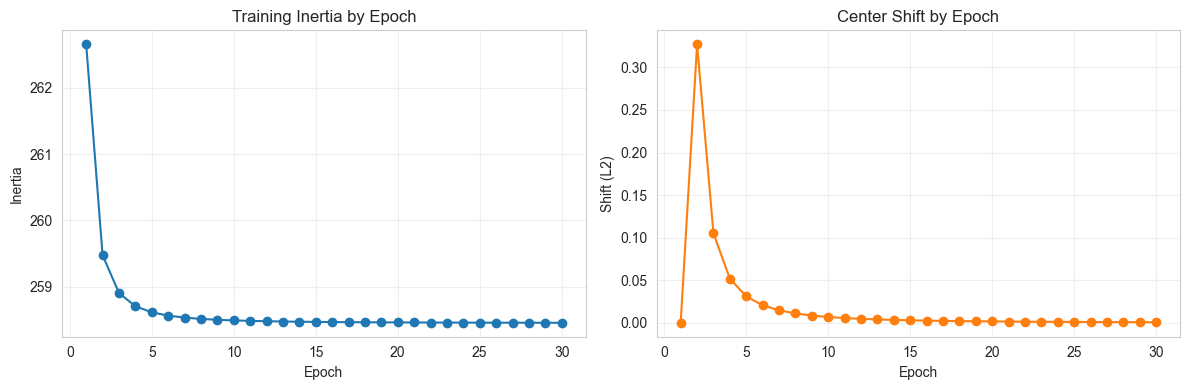

In [22]:
 # Fit with realtime epoch visualization
optimal_k = OPTIMAL_CLUSTERS

print(f"🎯 Fitting K-Means with K={optimal_k} (realtime epoch view)")

history = kmeans_model.fit_realtime(
    data=user_features_scaled,
    n_clusters=optimal_k,
    epochs=30,
    batch_size=256,
    display_every=1
)

print(f"\n✅ K-Means realtime training complete!")
print(f"\nFinal Metrics:")
print(f"  Silhouette Score: {kmeans_model.metrics['final_silhouette']:.4f}")
print(f"  Davies-Bouldin Index: {kmeans_model.metrics['final_davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz Score: {kmeans_model.metrics['final_calinski_harabasz']:.2f}")
print(f"  Final Inertia: {kmeans_model.metrics['inertia']:.2f}")

# Keep final training curves as a static summary figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['epoch'], history['inertia'], marker='o', color='tab:blue')
axes[0].set_title('Training Inertia by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['center_shift'], marker='o', color='tab:orange')
axes[1].set_title('Center Shift by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Shift (L2)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Analyze Clusters

In [23]:
# Get cluster statistics
cluster_stats, cluster_sizes = kmeans_model.analyze_clusters(
    data=user_features,
    feature_names=user_features.columns.tolist()
)

print("\n📊 Cluster Sizes:")
display(cluster_sizes)

INFO:src.clustering_model:Analyzing cluster characteristics...
INFO:src.clustering_model:
Cluster sizes:
INFO:src.clustering_model:  Cluster 0: 7.0 users (17.1%)
INFO:src.clustering_model:  Cluster 1: 13.0 users (31.7%)
INFO:src.clustering_model:  Cluster 2: 7.0 users (17.1%)
INFO:src.clustering_model:  Cluster 3: 13.0 users (31.7%)
INFO:src.clustering_model:  Cluster 4: 1.0 users (2.4%)



📊 Cluster Sizes:


,size,percentage
cluster,,
0,7,17.073171
1,13,31.707317
2,7,17.073171
3,13,31.707317
4,1,2.439024


In [24]:
print("\n📊 Cluster Statistics (Mean values):")
display(cluster_stats.xs('mean', level=1, axis=1))


📊 Cluster Statistics (Mean values):


,total_plays,unique_artists,unique_tracks,artist_diversity,track_diversity,listening_span_days,first_listen,last_listen,plays_per_day,top_artist_concentration,age,is_male,is_female
cluster,,,,,,,,,,,,,
0,19687.571429,359.857143,2501.000000,0.037049,0.213345,418.428571,2008-03-09 20:01:22+00:00,2009-05-02 21:47:01.142857216+00:00,70.547963,0.167698,23.214286,0.571429,0.142857
1,18610.538462,506.307692,3607.384615,0.030796,0.202201,1216.000000,2006-01-10 12:36:48+00:00,2009-05-10 23:53:10.692307712+00:00,15.506414,0.095398,21.846154,0.923077,0.000000
2,59749.571429,1342.285714,9612.571429,0.029107,0.195990,1237.285714,2005-12-16 00:10:08.857142912+00:00,2009-05-06 16:33:58.428571392+00:00,47.856546,0.044005,27.500000,0.285714,0.428571
3,13736.384615,817.692308,4525.000000,0.075987,0.382580,908.769231,2006-09-20 19:05:46.230769152+00:00,2009-03-17 23:55:38.692307712+00:00,15.862426,0.065651,24.846154,0.153846,0.769231
4,341.000000,100.000000,268.000000,0.293255,0.785924,917.000000,2006-10-26 17:50:31+00:00,2009-05-01 00:45:51+00:00,0.371460,0.105572,22.500000,0.000000,0.000000


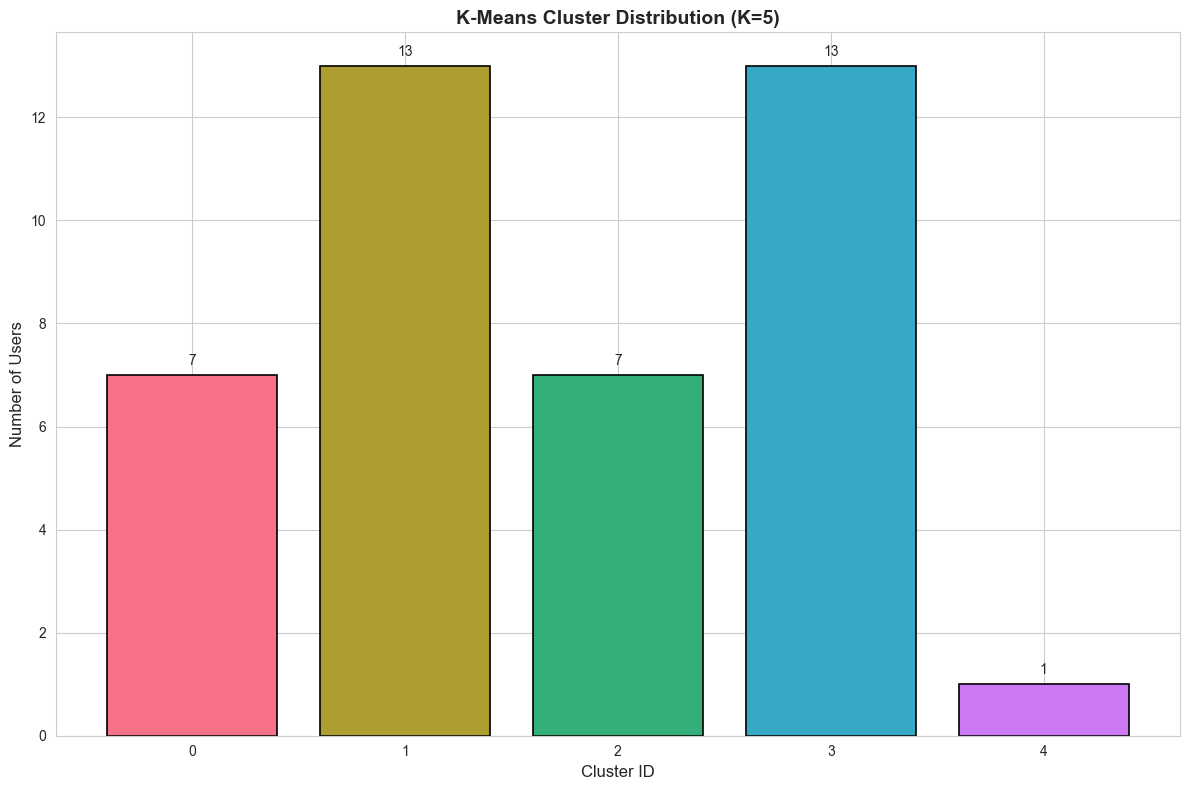

✅ Plot saved to: output/plots/kmeans_cluster_distribution.png


In [25]:
# Visualize cluster distribution
fig_cluster_dist = viz.plot_cluster_distribution(
    labels=kmeans_model.labels,
    title=f'K-Means Cluster Distribution (K={optimal_k})'
)

plt.savefig('../output/plots/kmeans_cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/kmeans_cluster_distribution.png")

### 4.4 Visualize Clusters in 2D (PCA)

In [26]:
# Reduce dimensions for visualization
data_2d, pca = kmeans_model.reduce_dimensions(
    data=user_features_scaled,
    n_components=2
)

print(f"\n📊 PCA Dimensionality Reduction:")
print(f"Original dimensions: {user_features_scaled.shape[1]}")
print(f"Reduced dimensions: {data_2d.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

INFO:src.clustering_model:Reducing dimensions to 2D using PCA...
INFO:src.clustering_model:Variance explained: 50.45%



📊 PCA Dimensionality Reduction:
Original dimensions: 11
Reduced dimensions: 2
Variance explained: 50.45%


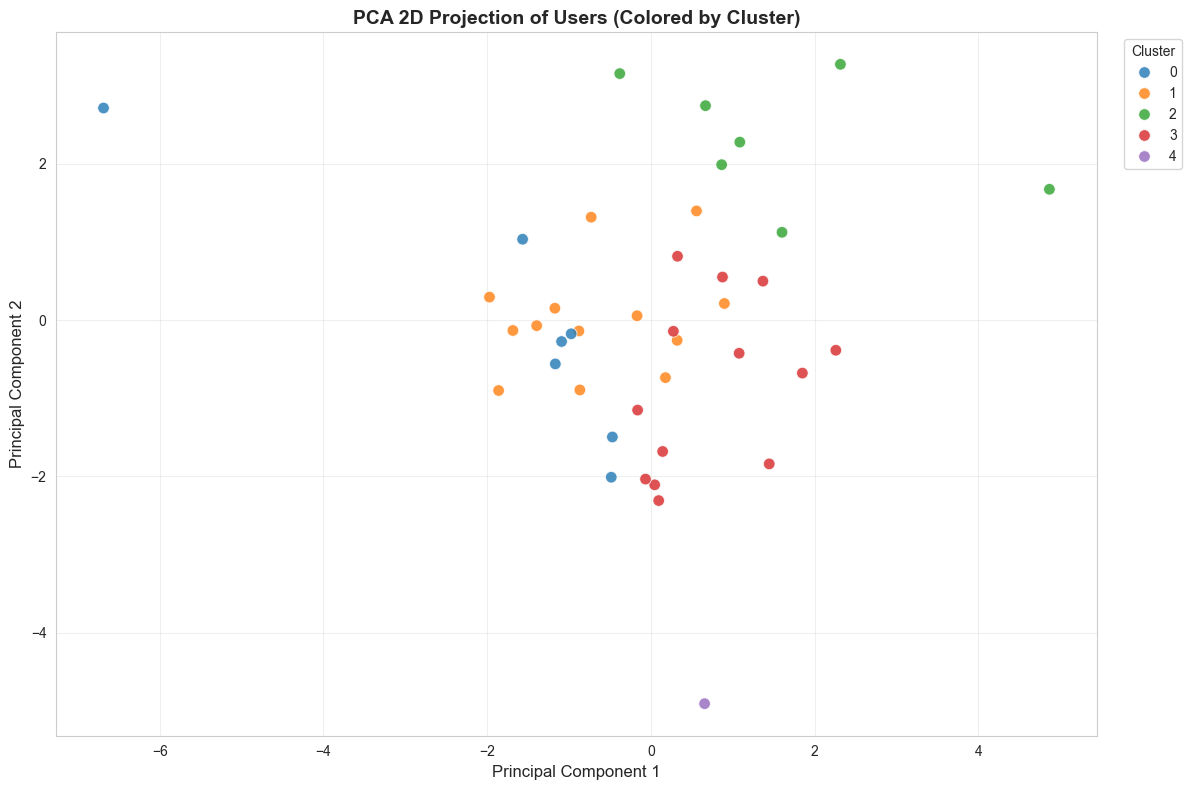

✅ Plot saved to: output/plots/pca_2d_scatter.png


In [27]:
# PCA 2D scatter plot (explicit view)
df_pca_2d = pd.DataFrame(data_2d, columns=['PC1', 'PC2'])
df_pca_2d['cluster'] = kmeans_model.labels

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=df_pca_2d,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    s=70,
    alpha=0.8,
    ax=ax
)

ax.set_title('PCA 2D Projection of Users (Colored by Cluster)', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.grid(alpha=0.3)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../output/plots/pca_2d_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Plot saved to: output/plots/pca_2d_scatter.png')

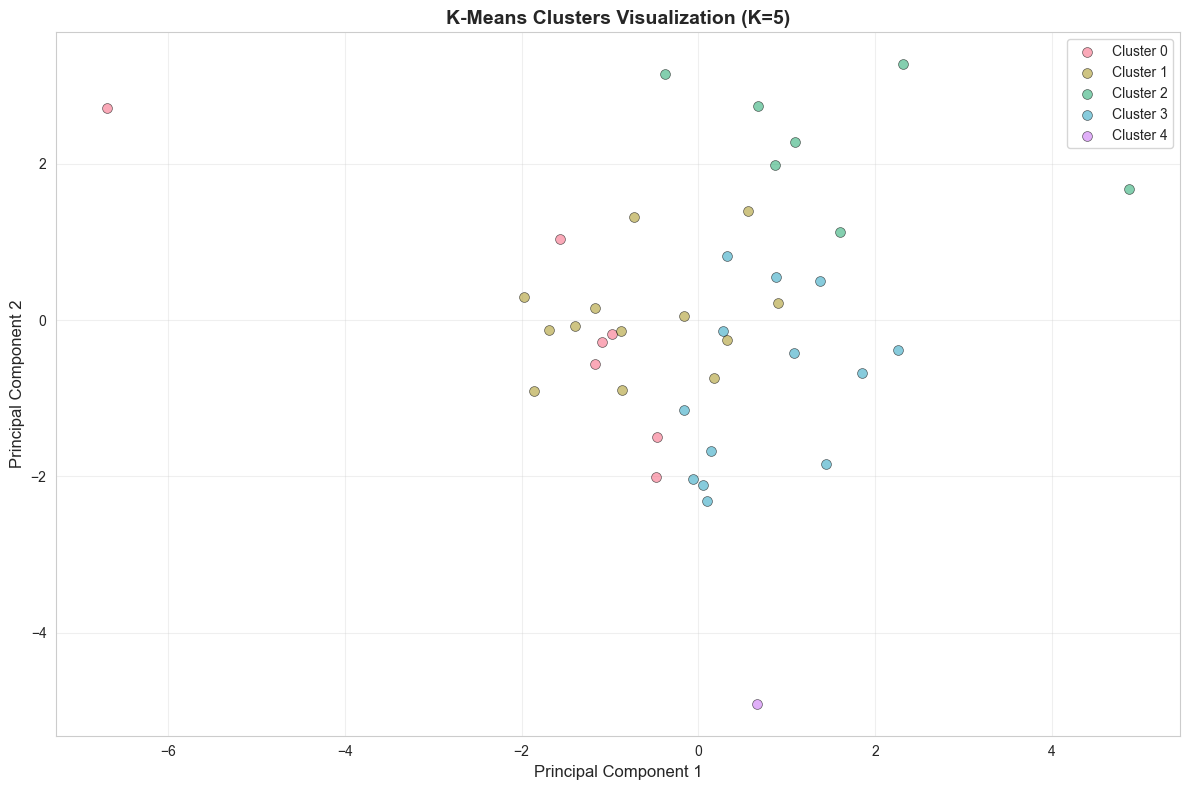

✅ Plot saved to: output/plots/kmeans_2d_clusters.png


In [28]:
# Plot 2D clusters
fig_2d = viz.plot_2d_clusters(
    data_2d=data_2d,
    labels=kmeans_model.labels,
    title=f'K-Means Clusters Visualization (K={optimal_k})'
)

plt.savefig('../output/plots/kmeans_2d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/kmeans_2d_clusters.png")

🔎 Building feature-importance heatmap from numeric user features...
feature_means_numeric shape: (5, 11)
numeric columns: ['total_plays', 'unique_artists', 'unique_tracks', 'artist_diversity', 'track_diversity', 'listening_span_days', 'plays_per_day', 'top_artist_concentration', 'age', 'is_male', 'is_female']
Top features selected (10): ['total_plays', 'unique_tracks', 'unique_artists', 'listening_span_days', 'plays_per_day', 'age', 'is_male', 'is_female', 'track_diversity', 'artist_diversity']


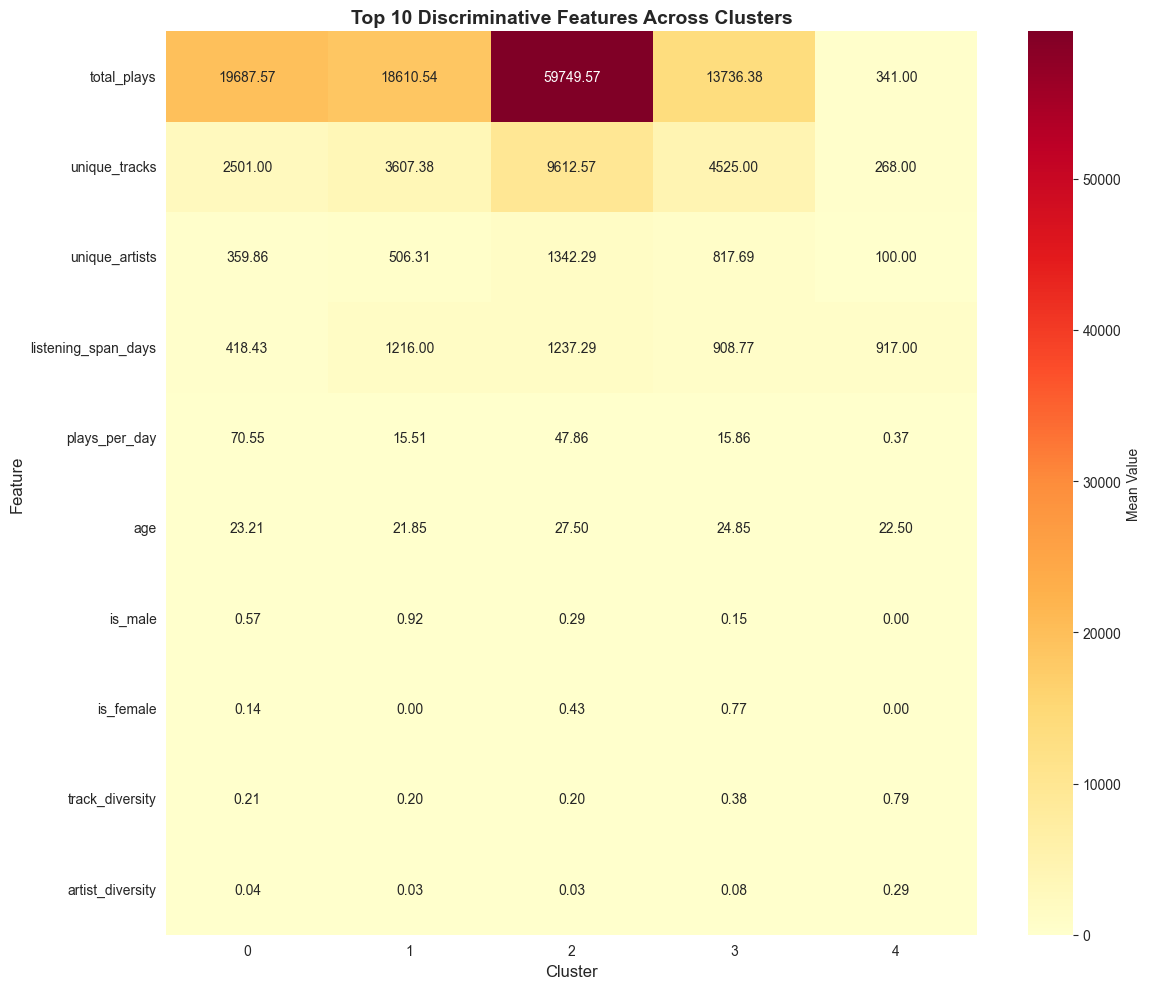

✅ Plot saved to: output/plots/kmeans_feature_importance.png


In [29]:
# Feature importance across clusters (self-healing + robust)
print("🔎 Building feature-importance heatmap from numeric user features...")

# Ensure required objects exist (so this cell can run independently)
if 'user_features' not in globals():
    print("ℹ️ 'user_features' not found. Rebuilding...")
    if 'feature_eng' not in globals():
        if 'listening_data' not in globals():
            raise ValueError("Missing 'listening_data'. Run data loading/preprocessing cells first.")
        profile_obj = profile_data if 'profile_data' in globals() else None
        feature_eng = FeatureEngineer(listening_data=listening_data, profile_data=profile_obj)
    user_features = feature_eng.create_user_features()

if 'kmeans_model' not in globals() or not hasattr(kmeans_model, 'labels') or kmeans_model.labels is None:
    print("ℹ️ 'kmeans_model.labels' not found. Fitting K-Means quickly...")
    if 'user_features_scaled' not in globals():
        user_features_scaled, _ = feature_eng.scale_features(user_features, method='standard')
    if 'optimal_k' not in globals():
        optimal_k = OPTIMAL_CLUSTERS if 'OPTIMAL_CLUSTERS' in globals() else 5
    kmeans_model = UserClusteringModel(random_state=RANDOM_STATE if 'RANDOM_STATE' in globals() else 42)
    kmeans_model.fit(data=user_features_scaled, n_clusters=optimal_k)

# 1) Build a clean numeric feature table
numeric_features = user_features.select_dtypes(include=[np.number]).copy()
if numeric_features.empty:
    raise ValueError("No numeric columns found in user_features.")

# 2) Attach cluster labels and compute per-cluster means
clustered_numeric = numeric_features.copy()
clustered_numeric['cluster'] = kmeans_model.labels
feature_means_numeric = clustered_numeric.groupby('cluster').mean(numeric_only=True)

if feature_means_numeric.empty:
    raise ValueError("Could not compute per-cluster numeric means.")

print(f"feature_means_numeric shape: {feature_means_numeric.shape}")
print(f"numeric columns: {feature_means_numeric.columns.tolist()}")

# 3) Rank features by variance across clusters
feature_variance = feature_means_numeric.var(axis=0).fillna(0)
feature_variance = feature_variance[feature_variance > 0]

if feature_variance.empty:
    raise ValueError("No varying numeric features across clusters (all variances are zero).")

top_n_effective = min(10, len(feature_variance))
top_features = feature_variance.nlargest(top_n_effective).index
print(f"Top features selected ({top_n_effective}): {list(top_features)}")

# 4) Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    feature_means_numeric[top_features].T,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Mean Value'},
    ax=ax
)

ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title(
    f'Top {top_n_effective} Discriminative Features Across Clusters',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('../output/plots/kmeans_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot saved to: output/plots/kmeans_feature_importance.png")

## 5. Bi-Clustering (Spectral Co-Clustering)

Bi-clustering approach - simultaneously cluster users AND artists to find coherent communities.

### 5.1 Fit Bi-Clustering Model

In [30]:
# Initialize bi-clustering model
bicluster_model = BiClusteringModel(random_state=RANDOM_STATE)

print(f"🎯 Fitting Bi-Clustering with {N_BICLUSTERS} bi-clusters")
print("This will cluster users AND artists simultaneously...")

bicluster_model.fit(
    user_artist_matrix=user_artist_matrix,
    n_clusters=N_BICLUSTERS
)

print(f"\n✅ Bi-clustering complete!")

INFO:src.biclustering_model:Fitting bi-clustering model with 4 bi-clusters...


🎯 Fitting Bi-Clustering with 4 bi-clusters
This will cluster users AND artists simultaneously...


INFO:src.biclustering_model:Bi-clustering complete.
INFO:src.biclustering_model:User clusters: [0 1 2 3]
INFO:src.biclustering_model:Artist clusters: [0 1 2 3]



✅ Bi-clustering complete!


In [31]:
# Get bi-cluster assignments
user_labels_bi, artist_labels_bi = bicluster_model.get_biclusters()

print(f"\n📊 Bi-Cluster Assignments:")
print(f"User clusters: {np.unique(user_labels_bi)}")
print(f"Artist clusters: {np.unique(artist_labels_bi)}")
print(f"\nUser label distribution: {np.bincount(user_labels_bi)}")
print(f"Artist label distribution: {np.bincount(artist_labels_bi)}")


📊 Bi-Cluster Assignments:
User clusters: [0 1 2 3]
Artist clusters: [0 1 2 3]

User label distribution: [35  1  1  4]
Artist label distribution: [8031  352   38 1606]


### 5.2 Analyze Bi-Clusters

In [32]:
# Analyze bi-cluster characteristics
bicluster_stats = bicluster_model.analyze_biclusters(
    user_artist_matrix=user_artist_matrix
)

print("\n📊 Bi-Cluster Statistics:")
display(bicluster_stats)

INFO:src.biclustering_model:Analyzing bi-cluster characteristics...
INFO:src.biclustering_model:
Bi-cluster statistics:
INFO:src.biclustering_model:  Bi-cluster 0: 35 users, 8031 artists, density=0.084
INFO:src.biclustering_model:  Bi-cluster 1: 1 users, 352 artists, density=1.000
INFO:src.biclustering_model:  Bi-cluster 2: 1 users, 38 artists, density=1.000
INFO:src.biclustering_model:  Bi-cluster 3: 4 users, 1606 artists, density=0.273



📊 Bi-Cluster Statistics:


,bicluster,n_users,n_artists,total_plays,avg_plays_per_user,avg_plays_per_artist,density
0,0,35,8031,672364.0,19210.4,83.721081,0.084498
1,1,1,352,88458.0,88458.0,251.301136,1.000000
2,2,1,38,35453.0,35453.0,932.973684,1.000000
3,3,4,1606,123404.0,30851.0,76.839352,0.273350


In [33]:
# Get top artists per bi-cluster
top_artists_per_bicluster = bicluster_model.get_top_artists_per_bicluster(
    user_artist_matrix=user_artist_matrix,
    top_n=10
)

print("\n🎵 Top Artists per Bi-Cluster:")
print("=" * 70)

for bicluster, artists in top_artists_per_bicluster.items():
    print(f"\nBi-Cluster {bicluster}:")
    for i, (artist, plays) in enumerate(artists.items(), 1):
        print(f"  {i:2d}. {artist:<40s} ({plays:.0f} plays)")
    print()

INFO:src.biclustering_model:Getting top 10 artists per bi-cluster...



🎵 Top Artists per Bi-Cluster:

Bi-Cluster 0:
   1. Radiohead                                (6754 plays)
   2. Nine Inch Nails                          (6481 plays)
   3. Sloan                                    (4993 plays)
   4. Muse                                     (4984 plays)
   5. Akira Yamaoka                            (4778 plays)
   6. Sonic Youth                              (4651 plays)
   7. Massive Attack                           (4601 plays)
   8. The Gathering                            (4505 plays)
   9. Air                                      (3657 plays)
  10. Depeche Mode                             (3517 plays)


Bi-Cluster 1:
   1. Dir En Grey                              (12005 plays)
   2. ムック                                      (7788 plays)
   3. 雅-Miyavi-                                (6018 plays)
   4. Acidman                                  (4293 plays)
   5. Mucc                                     (3694 plays)
   6. Sads                           

### 5.3 Visualize Bi-Clusters

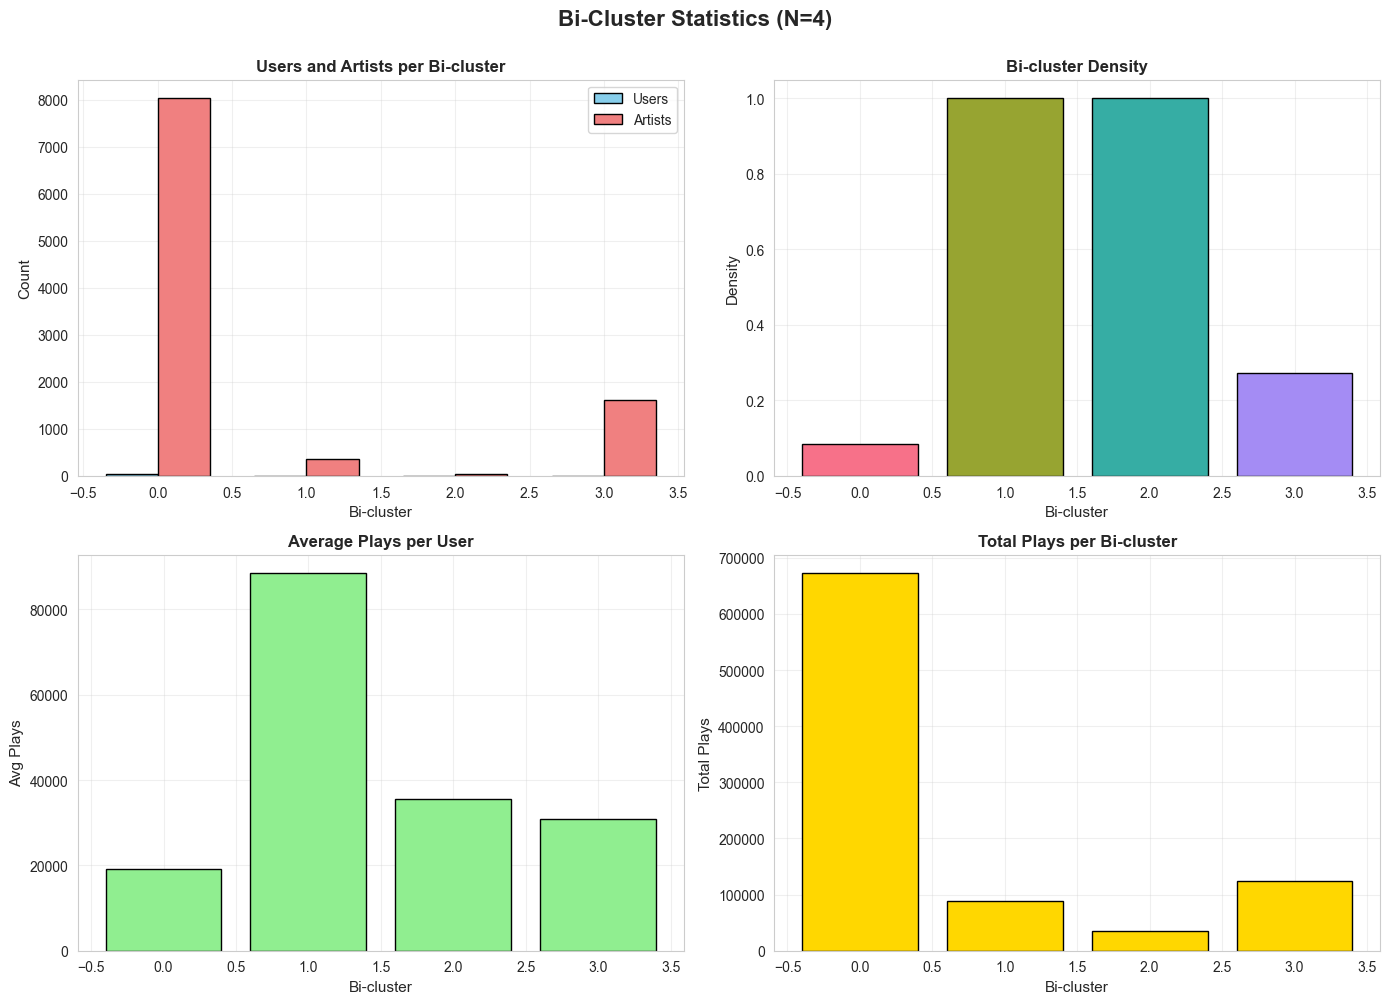

✅ Plot saved to: output/plots/bicluster_statistics.png


In [34]:
# Plot bi-cluster statistics
fig_bicluster_stats = viz.plot_bicluster_statistics(
    bicluster_stats=bicluster_stats,
    title=f'Bi-Cluster Statistics (N={N_BICLUSTERS})'
)

plt.savefig('../output/plots/bicluster_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/bicluster_statistics.png")

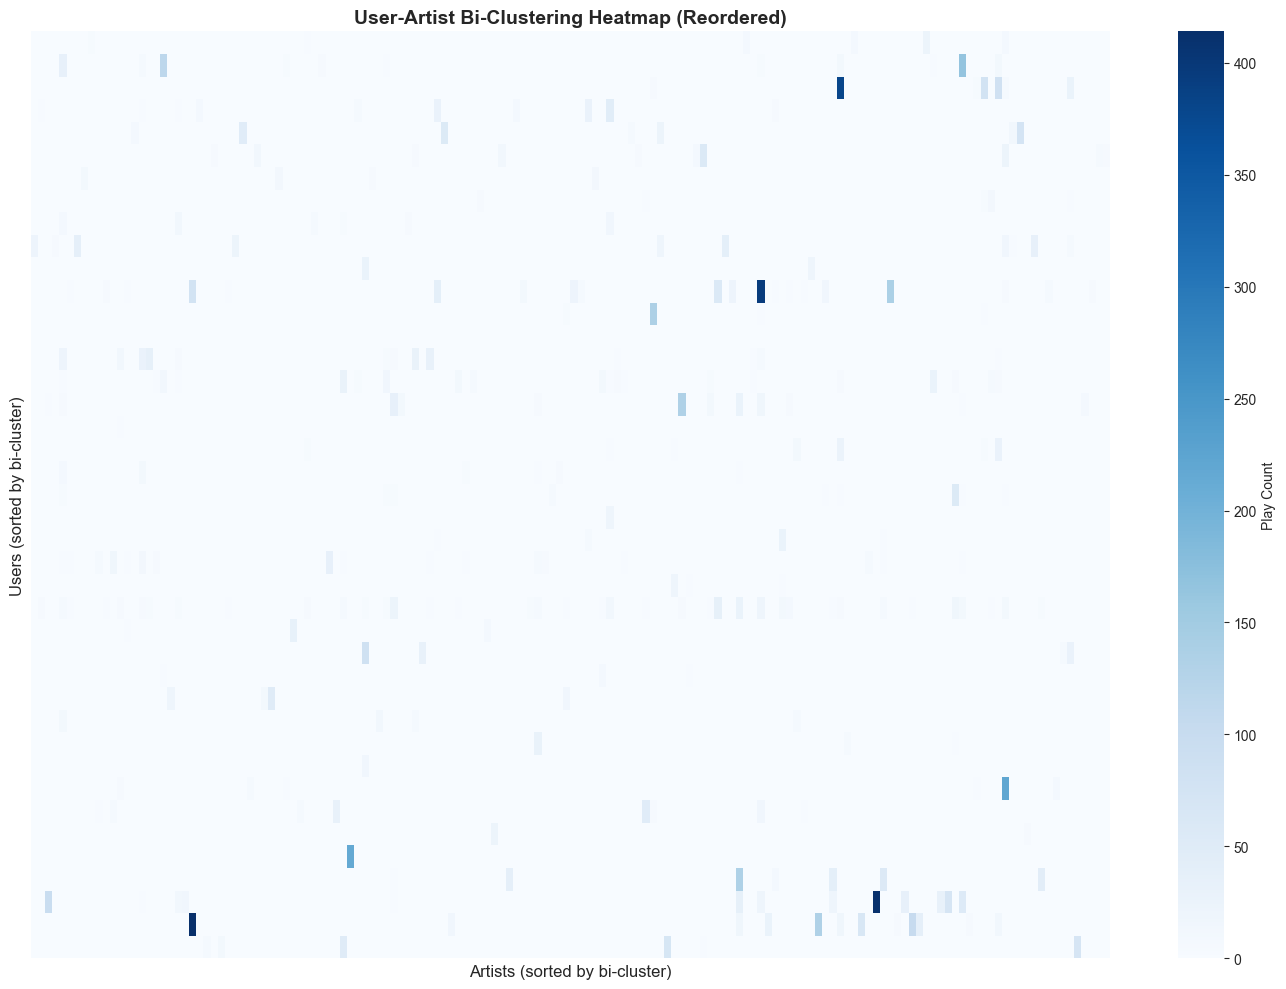

✅ Plot saved to: output/plots/bicluster_heatmap.png


In [35]:
# Plot bi-cluster heatmap
fig_heatmap = viz.plot_bicluster_heatmap(
    user_artist_matrix=user_artist_matrix,
    user_labels=user_labels_bi,
    artist_labels=artist_labels_bi,
    sample_size=150,
    title='User-Artist Bi-Clustering Heatmap (Reordered)'
)

plt.savefig('../output/plots/bicluster_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/bicluster_heatmap.png")

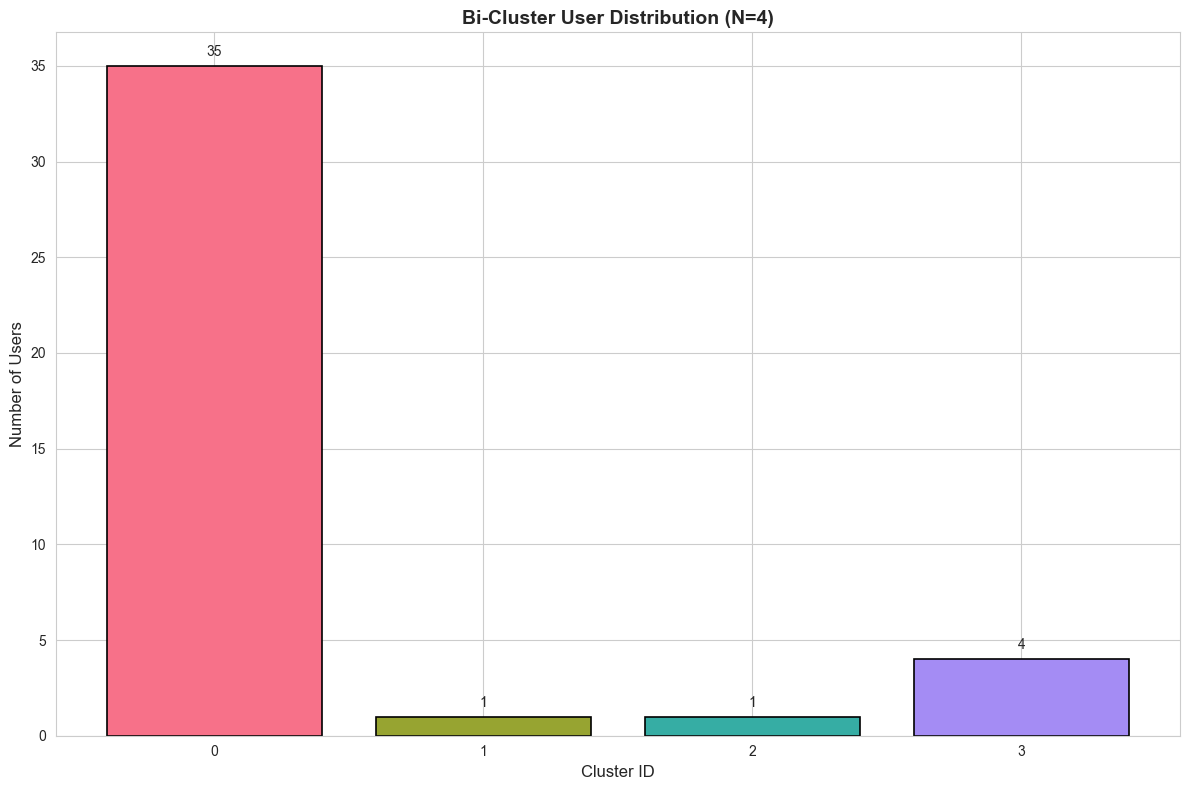

✅ Plot saved to: output/plots/bicluster_user_distribution.png


In [36]:
# Visualize bi-cluster user distribution
fig_bi_dist = viz.plot_cluster_distribution(
    labels=user_labels_bi,
    title=f'Bi-Cluster User Distribution (N={N_BICLUSTERS})'
)

plt.savefig('../output/plots/bicluster_user_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: output/plots/bicluster_user_distribution.png")

## 6. Model Comparison

Compare K-Means clustering vs Bi-Clustering using multiple metrics.

### 6.1 Evaluate Both Models

In [37]:
# Initialize comparison
comparison = ModelComparison()

# Evaluate K-Means
kmeans_metrics = comparison.evaluate_clustering(
    data=user_features_scaled,
    labels=kmeans_model.labels,
    model_name="K-Means Clustering"
)

print("\n" + "=" * 70)

INFO:src.evaluation:Evaluating K-Means Clustering...
INFO:src.evaluation:  Silhouette Score: 0.1689
INFO:src.evaluation:  Davies-Bouldin Score: 1.4064
INFO:src.evaluation:  Calinski-Harabasz Score: 6.7052


In [38]:
# Evaluate Bi-Clustering
bicluster_metrics = comparison.evaluate_biclustering(
    user_artist_matrix=user_artist_matrix,
    user_labels=user_labels_bi,
    artist_labels=artist_labels_bi,
    model_name="Bi-Clustering"
)

print("\n" + "=" * 70)

INFO:src.evaluation:Evaluating Bi-Clustering...
INFO:src.evaluation:  Number of bi-clusters: 4
INFO:src.evaluation:  Average bi-cluster density: 0.5895
INFO:src.evaluation:  User coverage: 100.00%
INFO:src.evaluation:  Artist coverage: 100.00%


### 6.2 Compare User Assignments

In [39]:
# Compare how users are clustered in both approaches
user_comparison = comparison.compare_user_clustering(
    clustering_labels=kmeans_model.labels,
    biclustering_labels=user_labels_bi
)

print("\n📊 User Assignment Agreement:")
print(f"  Adjusted Rand Index: {user_comparison['adjusted_rand_index']:.4f}")
print(f"  Normalized Mutual Info: {user_comparison['normalized_mutual_info']:.4f}")
print()
print("Interpretation:")
print("  - ARI close to 1: High agreement (similar clusters)")
print("  - ARI close to 0: Low agreement (different perspectives)")
print("  - NMI close to 1: High mutual information")

INFO:src.evaluation:Comparing user clustering assignments...
INFO:src.evaluation:  Adjusted Rand Index: 0.0978
INFO:src.evaluation:  Normalized Mutual Information: 0.2207



📊 User Assignment Agreement:
  Adjusted Rand Index: 0.0978
  Normalized Mutual Info: 0.2207

Interpretation:
  - ARI close to 1: High agreement (similar clusters)
  - ARI close to 0: Low agreement (different perspectives)
  - NMI close to 1: High mutual information


In [40]:
# Analyze user migration between models
migration_df, crosstab = comparison.analyze_user_migration(
    user_ids=user_artist_matrix.index.values,
    clustering_labels=kmeans_model.labels,
    biclustering_labels=user_labels_bi
)

print("\n📊 User Migration Between Models:")
print("\nCross-tabulation (K-Means vs Bi-Clustering):")
display(crosstab)

INFO:src.evaluation:Analyzing user migration between models...
INFO:src.evaluation:
User distribution cross-tabulation:
INFO:src.evaluation:
bicluster        0  1  2  3  All
kmeans_cluster                  
0                4  0  1  2    7
1               13  0  0  0   13
2                4  1  0  2    7
3               13  0  0  0   13
4                1  0  0  0    1
All             35  1  1  4   41



📊 User Migration Between Models:

Cross-tabulation (K-Means vs Bi-Clustering):


bicluster,0,1,2,3,All
kmeans_cluster,,,,,
0,4,0,1,2,7
1,13,0,0,0,13
2,4,1,0,2,7
3,13,0,0,0,13
4,1,0,0,0,1
All,35,1,1,4,41


### 6.4 Summary Report

In [43]:
# Print comprehensive summary
summary = comparison.get_summary()
print(summary)

# Save to file
with open('../output/results/comparison_summary.txt', 'w') as f:
    f.write(summary)

print(f"\n✅ Summary saved to: output/results/comparison_summary.txt")

MODEL COMPARISON SUMMARY

K-Means Clustering:
  n_clusters: 5
  silhouette_score: 0.1689
  davies_bouldin_score: 1.4064
  calinski_harabasz_score: 6.7052
  cluster_balance: 0.5476

Bi-Clustering:
  n_user_clusters: 4
  n_artist_clusters: 4
  n_biclusters: 4
  avg_bicluster_density: 0.5895
  avg_bicluster_size: 71974.7500
  user_coverage: 1.0000
  artist_coverage: 1.0000
  user_cluster_balance: 1.3992

Clustering vs Bi-Clustering Agreement:
  Adjusted Rand Index: 0.0978
  Normalized Mutual Info: 0.2207

✅ Summary saved to: output/results/comparison_summary.txt


### 6.5 User Behavior Grouping

In [ ]:
# Build user behavior groups from listening features
behavior_df = user_features.copy().reset_index().rename(columns={'index': 'userid'})

if 'userid' not in behavior_df.columns:
    behavior_df.insert(0, 'userid', user_artist_matrix.index.values)

behavior_df['kmeans_cluster'] = kmeans_model.labels

required_cols = ['total_plays', 'unique_artists', 'unique_tracks', 'artist_diversity']
missing_cols = [c for c in required_cols if c not in behavior_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns for behavior grouping: {missing_cols}")

plays_q = behavior_df['total_plays'].quantile([0.33, 0.66]).values
diversity_q = behavior_df['artist_diversity'].quantile([0.33, 0.66]).values


def assign_behavior_group(row):
    heavy = row['total_plays'] >= plays_q[1]
    light = row['total_plays'] <= plays_q[0]
    high_diversity = row['artist_diversity'] >= diversity_q[1]
    low_diversity = row['artist_diversity'] <= diversity_q[0]

    if heavy and high_diversity:
        return 'Power Explorers'
    if heavy and low_diversity:
        return 'Power Focused'
    if light and high_diversity:
        return 'Casual Explorers'
    if light and low_diversity:
        return 'Casual Focused'
    return 'Balanced Listeners'


behavior_df['behavior_group'] = behavior_df.apply(assign_behavior_group, axis=1)

print("\n📊 User behavior grouping summary:")
display(
    behavior_df.groupby('behavior_group')
    .agg(
        n_users=('userid', 'count'),
        avg_total_plays=('total_plays', 'mean'),
        avg_unique_artists=('unique_artists', 'mean'),
        avg_artist_diversity=('artist_diversity', 'mean')
    )
    .sort_values('n_users', ascending=False)
)

print("\n📋 Sample grouped users:")
display(behavior_df[['userid', 'kmeans_cluster', 'behavior_group', 'total_plays', 'unique_artists', 'artist_diversity']].head(20))

behavior_output_path = '../output/results/user_behavior_groups.csv'
behavior_df.to_csv(behavior_output_path, index=False)
print(f"\n✅ User behavior groups saved to: {behavior_output_path}")

## 7. Insights and Interpretation

### Key Findings

#### K-Means Clustering
**Strengths:**
- Groups users with similar overall listening behaviors
- Easy to interpret with standard metrics
- Computationally efficient
- Good for user segmentation and profiling

**Use Cases:**
- User persona development
- Targeted marketing campaigns
- Personalized UI/UX
- Broad recommendation strategies

#### Bi-Clustering
**Strengths:**
- Discovers user-artist communities simultaneously
- Identifies niche music preferences
- Higher granularity for specific recommendations
- Captures artist-specific fan bases

**Use Cases:**
- Artist recommendation systems
- Music discovery features
- Genre/sub-genre identification
- Community-based recommendations

### Model Agreement
The Adjusted Rand Index and Normalized Mutual Information scores indicate how much the two approaches agree on user groupings. Lower agreement suggests they capture different aspects of user behavior.

### Practical Recommendations
1. **Use K-Means** for broad user segmentation and profiling
2. **Use Bi-Clustering** for specific music/artist recommendations
3. **Combine both** for a hybrid recommendation system
4. Consider user's cluster for UI personalization
5. Consider bi-cluster for music discovery features

## 8. Save Models and Results

In [44]:
# Save models
save_model(kmeans_model, '../output/models/kmeans_model.pkl')
save_model(bicluster_model, '../output/models/bicluster_model.pkl')
save_model(scaler, '../output/models/feature_scaler.pkl')

print("✅ Models saved!")

INFO:src.utils:Saving model to ../output/models/kmeans_model.pkl...
INFO:src.utils:Model saved successfully.
INFO:src.utils:Saving model to ../output/models/bicluster_model.pkl...
INFO:src.utils:Model saved successfully.
INFO:src.utils:Saving model to ../output/models/feature_scaler.pkl...
INFO:src.utils:Model saved successfully.


✅ Models saved!


In [46]:
# Save results
results = {
    'dataset_stats': stats,
    'kmeans_metrics': kmeans_metrics,
    'bicluster_metrics': bicluster_metrics,
    'comparison_metrics': user_comparison,
    'optimal_k': optimal_k,
    'n_biclusters': N_BICLUSTERS
}

save_results(results, '../output/results/analysis_results.json')

print("✅ Results saved!")

INFO:src.utils:Saving results to ../output/results/analysis_results.json...
INFO:src.utils:Results saved successfully.


✅ Results saved!


In [47]:
# Save user assignments
user_assignments = pd.DataFrame({
    'userid': user_artist_matrix.index,
    'kmeans_cluster': kmeans_model.labels,
    'bicluster': user_labels_bi
})

user_assignments.to_csv('../output/results/user_cluster_assignments.csv', index=False)

print("✅ User assignments saved!")
print(f"\nSample assignments:")
display(user_assignments.head(10))

✅ User assignments saved!

Sample assignments:


,userid,kmeans_cluster,bicluster
0,user_000001,1,0
1,user_000002,2,0
2,user_000003,1,0
3,user_000004,3,0
4,user_000005,1,0
5,user_000006,3,0
6,user_000007,3,0
7,user_000008,0,2
8,user_000009,3,0
9,user_000010,1,0


## 9. Conclusion

This project successfully implemented and compared two clustering approaches for music recommendation:

### 📊 Summary
- **Dataset**: Last.fm-1K with 992 users and 177K+ artists
- **Approach 1**: K-Means clustering on user features
- **Approach 2**: Bi-clustering on user-artist matrix

### 🎯 Key Takeaways
1. **Different Perspectives**: Both methods provide complementary views of user behavior
2. **K-Means**: Better for broad user segmentation
3. **Bi-Clustering**: Better for specific music recommendations
4. **Hybrid Approach**: Combining both could yield optimal results

### 📈 Model Performance
- Both models showed meaningful user groupings
- Bi-clustering successfully identified user-artist communities
- Agreement metrics indicate they capture different aspects

### 🚀 Future Work
- Experiment with different clustering algorithms (DBSCAN, Hierarchical)
- Try other bi-clustering methods (Spectral Biclustering)
- Incorporate temporal dynamics
- Build actual recommendation system
- A/B testing in production

---

**Project Complete! ✅**